In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# EDA

--- Primeiras Linhas ---
   renda_mensal  idade sexo historico_credito  credito_aprovado
0   6670.125603     48    m               bom                 0
1   5906.280922     60    M           regular                 0
2   5268.201825     69    F               bom                 0
3   3266.537872     65    F              ruim                 0
4   4989.075022     26    M           regular                 0

--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   renda_mensal       350 non-null    float64
 1   idade              350 non-null    int64  
 2   sexo               350 non-null    str    
 3   historico_credito  350 non-null    str    
 4   credito_aprovado   350 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 13.8 KB
None

--- Resumo Estatístico (Numérico) ---


,renda_mensal,idade,credito_aprovado
count,350.000000,350.000000,350.000000
mean,5061.666924,45.700000,0.288571
std,1458.129379,14.697475,0.453747
min,1000.000000,18.000000,0.000000
25%,4008.983904,34.000000,0.000000
50%,5064.348670,47.000000,0.000000
75%,6155.250751,58.000000,1.000000
max,9159.956278,69.000000,1.000000


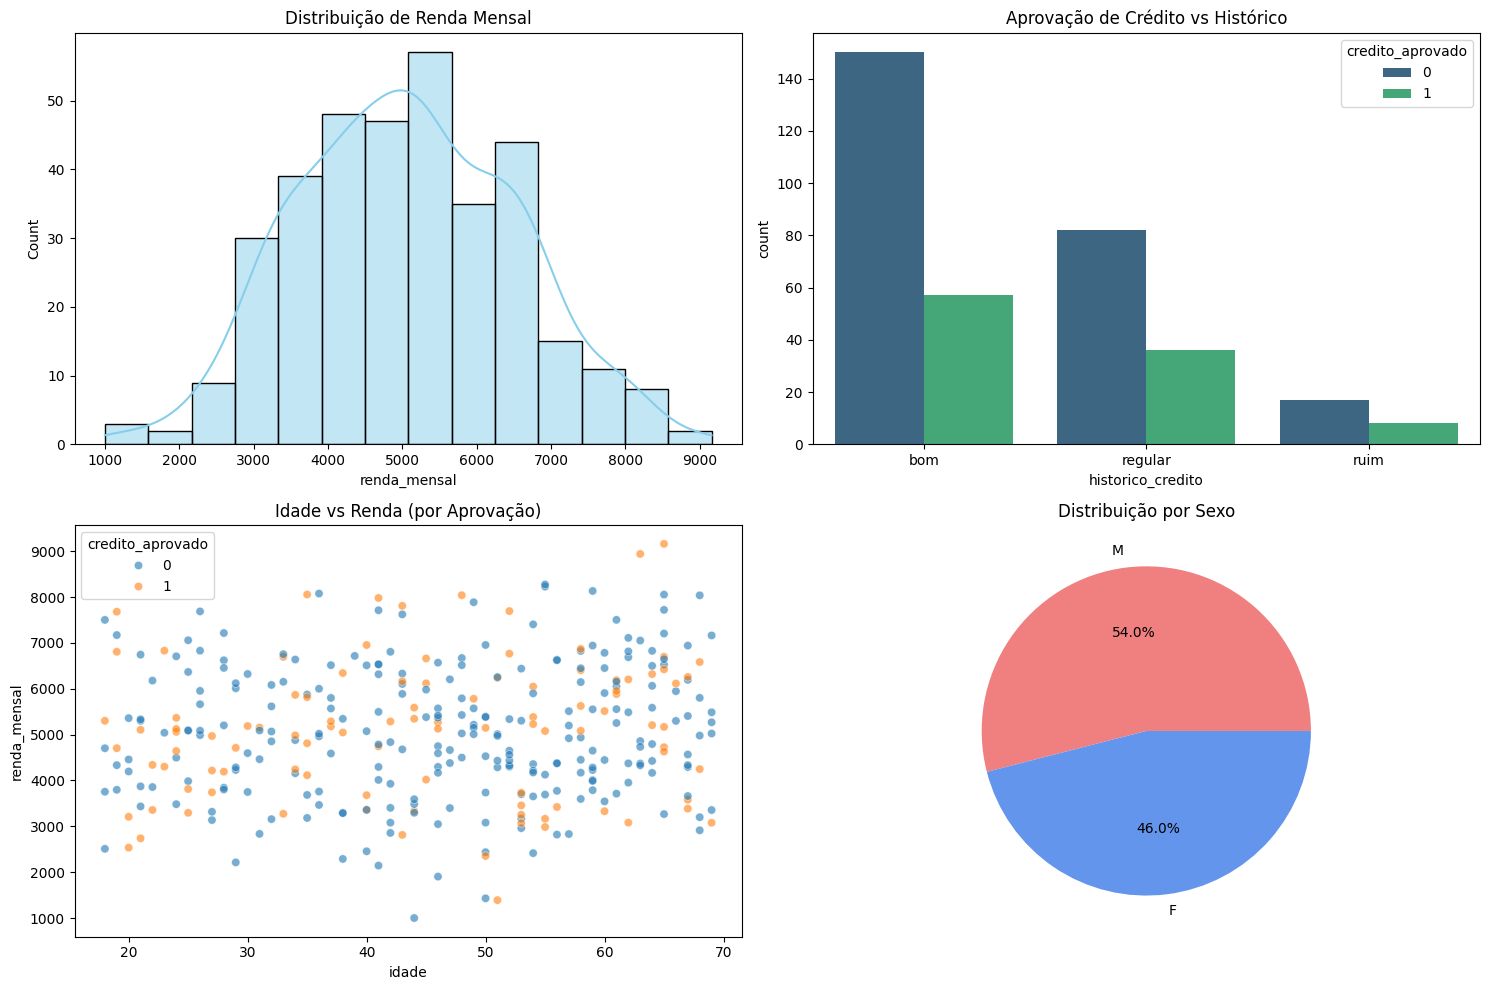

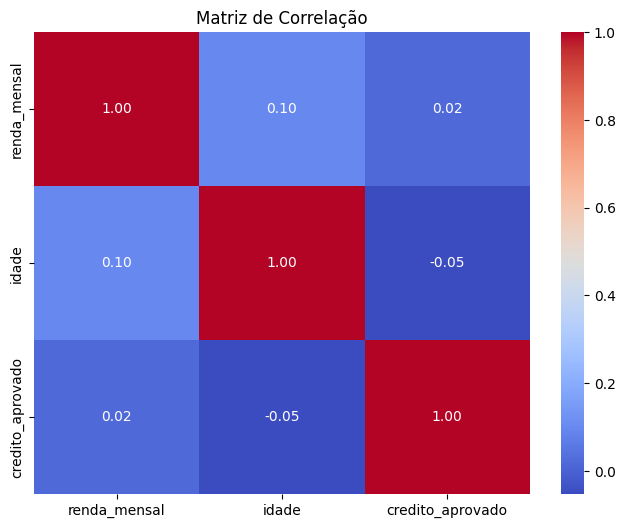

In [7]:
df = pd.read_csv("credito.csv")
df

# 1. Carregamento e Inspeção Inicial
print("--- Primeiras Linhas ---")
print(df.head())

print("\n--- Informações do Dataset ---")
print(df.info())

# 2. Limpeza de Dados (Normalização de strings)
# Notei no snippet que 'sexo' tem 'M', 'm', 'F', 'f'. Vamos padronizar.
df['sexo'] = df['sexo'].str.upper()

# 3. Análise Estatística Descritiva
print("\n--- Resumo Estatístico (Numérico) ---")
display(df.describe())

# 4. Visualização de Dados
plt.figure(figsize=(15, 10))

# Distribuição da Renda Mensal
plt.subplot(2, 2, 1)
sns.histplot(df['renda_mensal'], kde=True, color='skyblue')
plt.title('Distribuição de Renda Mensal')

# Aprovação de Crédito por Histórico
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='historico_credito', hue='credito_aprovado', palette='viridis')
plt.title('Aprovação de Crédito vs Histórico')

# Relação Idade e Renda
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='idade', y='renda_mensal', hue='credito_aprovado', alpha=0.6)
plt.title('Idade vs Renda (por Aprovação)')

# Proporção de Gênero
plt.subplot(2, 2, 4)
df['sexo'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'cornflowerblue'])
plt.title('Distribuição por Sexo')

plt.tight_layout()
plt.show()

# 5. Correlação (apenas colunas numéricas)
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

In [8]:
df['credito_aprovado'].value_counts()

credito_aprovado
0    249
1    101
Name: count, dtype: int64

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Transformação de variáveis categóricas (One-Hot Encoding)
df = pd.get_dummies(df, columns=['sexo', 'historico_credito'], drop_first=True)

X = df.drop('credito_aprovado', axis=1)
y = df['credito_aprovado']

# 2. Holdout (Divisão Treino e Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Balanceamento com SMOTE
# Aplicado apenas no conjunto de treino para evitar vazamento de dados (Data Leakage)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Normalização (Essencial para modelos lineares e convergência de solvers)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 5. Otimização de Hiperparâmetros (Testando Solvers)
param_grid = {
    'solver': ['liblinear', 'lbfgs', 'newton-cg', 'saga'],
    'C': [0.1, 1.0, 10.0], # Parâmetro de regularização
    'max_iter': [1000]     # Garantir convergência
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_res)

# Escolhendo o melhor modelo
best_model = grid_search.best_estimator_
print(f"Melhor Solver encontrado: {grid_search.best_params_['solver']}")

# 6. Avaliação do Modelo
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Melhor Solver encontrado: liblinear

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.66      0.49      0.56        75
           1       0.22      0.37      0.28        30

    accuracy                           0.46       105
   macro avg       0.44      0.43      0.42       105
weighted avg       0.54      0.46      0.48       105


--- Matriz de Confusão ---
[[37 38]
 [19 11]]

ROC AUC Score: 0.5142


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE

# 1. Carregamento
df = pd.read_csv('credito.csv')
df['sexo'] = df['sexo'].str.upper()

# --- FEATURE ENGINEERING AVANÇADA ---

# A. Log da Renda (estabiliza a variância)
df['log_renda'] = np.log1p(df['renda_mensal'])

# B. Bucketing de Idade (Criando categorias)
df['is_jovem'] = (df['idade'] < 25).astype(int)
df['is_senior'] = (df['idade'] > 60).astype(int)

# C. One-Hot Encoding das categorias
df = pd.get_dummies(df, columns=['sexo', 'historico_credito'], drop_first=True)

# D. Criando Interações (Renda x Histórico de Crédito)
# Se o histórico for bom (historico_credito_bom == 1), potencializa a renda
if 'historico_credito_bom' in df.columns:
    df['renda_vs_historico'] = df['renda_mensal'] * df['historico_credito_bom']

X = df.drop(['credito_aprovado', 'renda_mensal'], axis=1) # Usamos log_renda no lugar
y = df['credito_aprovado']

# 2. Holdout
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 3. SMOTE para equilibrar as classes
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Polynomial Features (Gera combinações automáticas entre as colunas)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_res)
X_test_poly = poly.transform(X_test)

# 5. Escalonamento (Obrigatório para Regressão Logística com interações)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# 6. Grid Search focado em Solvers e Regularização (C)
# C menor = mais regularização (evita overfitting das interações que criamos)
param_grid = {
    'solver': ['liblinear', 'saga'],
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train_res)

# 7. Resultados
best_model = grid_search.best_estimator_
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Melhor C: {grid_search.best_params_['C']}")
print(f"Novo ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nRelatório de Classificação:\n", classification_report(y_test, best_model.predict(X_test_scaled)))

c:\Users\joaoh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\joaoh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\joaoh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Melhor C: 0.001
Novo ROC AUC: 0.5149

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.73      0.70      0.72        63
           1       0.32      0.36      0.34        25

    accuracy                           0.60        88
   macro avg       0.53      0.53      0.53        88
weighted avg       0.62      0.60      0.61        88



c:\Users\joaoh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
